In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'D:\Jupyter notebook\titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [11]:
# 检查缺失值
print(df.isnull().sum())
# 删除缺失值
df_cleaned = df.dropna()
# 删除重复值
df = df.drop_duplicates()
# 处理异常值
import matplotlib.pyplot as plt
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            162
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          661
Embarked         0
dtype: int64


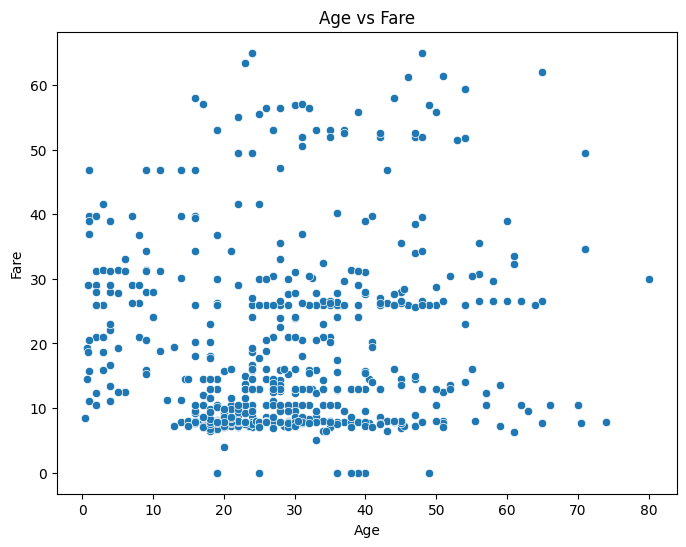

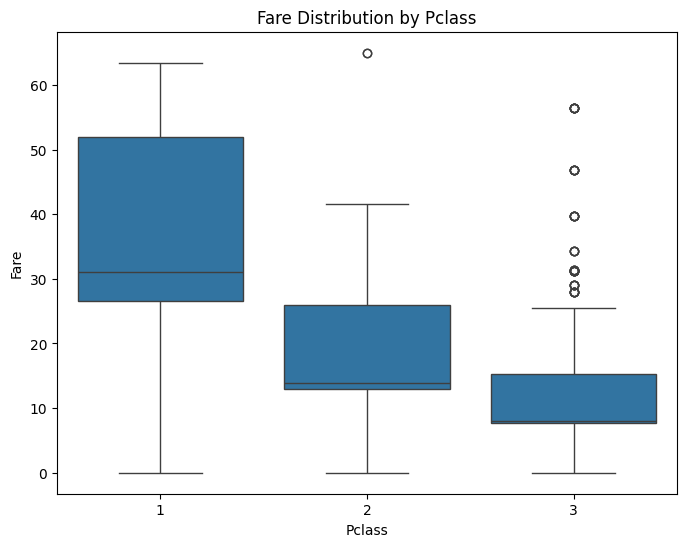

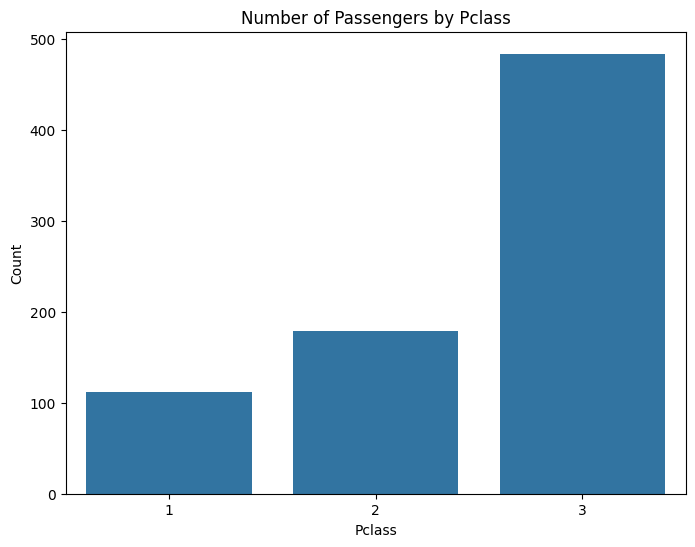

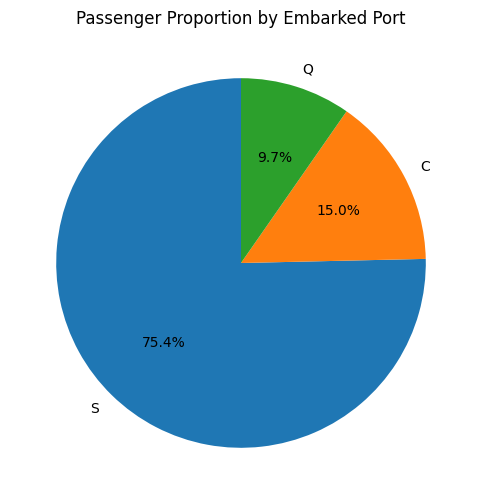

In [5]:
# 导入可视化库
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  散点图：查看Age和Fare的关系
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title('Age vs Fare')
plt.show()

# 4.2 箱线图：查看不同船舱等级(Pclass)下的票价(Fare)分布
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare Distribution by Pclass')
plt.show()


#柱状图 - 不同舱位等级（Pclass）的乘客数量
plt.figure(figsize=(8, 6))
sns.countplot(x='Pclass', data=df)
plt.title('Number of Passengers by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Count')
plt.show()



#饼图 - 不同登船港口（Embarked）的乘客比例
embarked_counts = df['Embarked'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(embarked_counts, labels=embarked_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Passenger Proportion by Embarked Port')
plt.show()

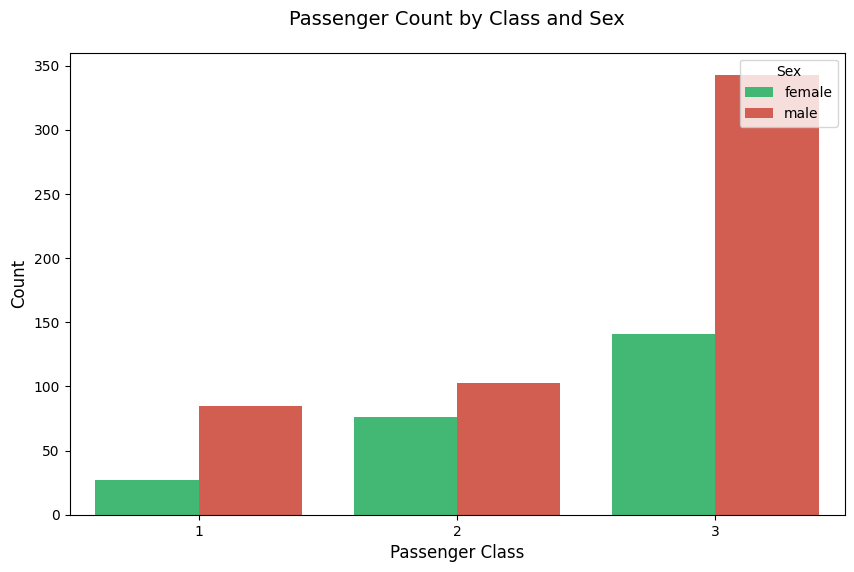

In [10]:
plt.figure(figsize=(10, 6))
sns.countplot(
    x='Pclass', 
    hue='Sex', 
    data=df, 
    palette={'male': '#e74c3c', 'female': '#2ecc71'}  # 男红女绿
)
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Passenger Count by Class and Sex', fontsize=14, pad=20)
plt.legend(title='Sex', loc='upper right')
plt.show()